# Comparative Evaluation of Ensemble Learning Methods for Fraud Detection
<center>

##  Course Details

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 5 Ensemble Learning Methods
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>


# Importing of Packages

In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt


# Data Exploration and Visualization

In [90]:
dataf = pd.read_csv("../../Datasets/creditcard.csv")
dataf.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [91]:
# Describe the dataset
dataf.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [92]:
# Check dataset collumn datatypes
dataf.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [93]:
# Count missing values per column
dataf.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Data Preprocessing

In [94]:
X = dataf.drop(columns=["Class"])
y = dataf["Class"].astype(int)

In [95]:
scaler = StandardScaler()
# Fit on X and transform
X_scaled = scaler.fit_transform(X)

In [96]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Decision Tree Classifier

Accuracy: 0.9994031056064183
Precision: 0.8603351955307262
Recall: 0.7817258883248731
F1-score: 0.8191489361702128

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113726
           1       0.86      0.78      0.82       197

    accuracy                           1.00    113923
   macro avg       0.93      0.89      0.91    113923
weighted avg       1.00      1.00      1.00    113923



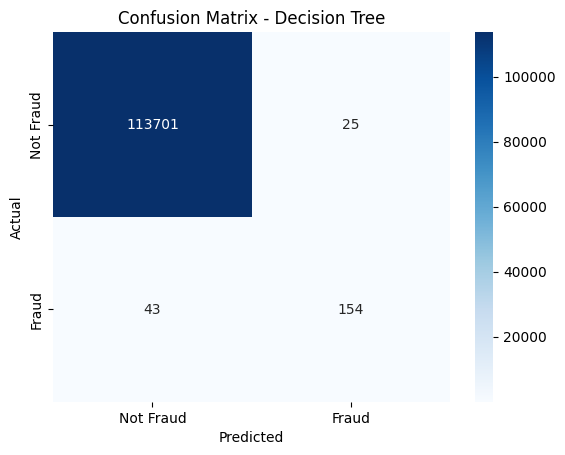

In [97]:


dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # you can tune max_depth
dt_model.fit(X_train, y_train)

# ---  Predict ---
y_pred = dt_model.predict(X_test)

# --- Evaluate ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud","Fraud"],
            yticklabels=["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Random Forest Classifier (Bagging)

Accuracy: 0.9994645506175224
Precision: 0.9594594594594594
Recall: 0.7208121827411168
F1-score: 0.8231884057971014

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113726
           1       0.96      0.72      0.82       197

    accuracy                           1.00    113923
   macro avg       0.98      0.86      0.91    113923
weighted avg       1.00      1.00      1.00    113923



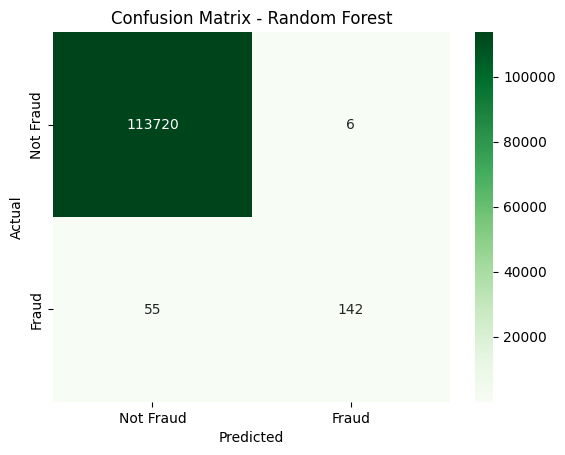

In [98]:

# --- Train Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    random_state=42,
    class_weight="balanced", # handle imbalanced fraud data
    max_depth=None           # let trees grow fully (can tune)
)
rf_model.fit(X_train, y_train)

# --- Predict ---
y_pred_rf = rf_model.predict(X_test)

# --- Evaluate ---
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Not Fraud","Fraud"],
            yticklabels=["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# AdaBoost Classifier (Boosting)

Accuracy: 0.9990519912572527
Precision: 0.7730061349693251
Recall: 0.6395939086294417
F1-score: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    113726
           1       0.77      0.64      0.70       197

    accuracy                           1.00    113923
   macro avg       0.89      0.82      0.85    113923
weighted avg       1.00      1.00      1.00    113923



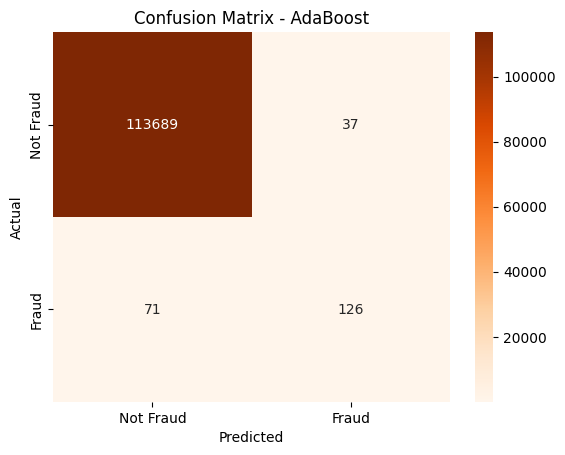

In [99]:

# --- Base estimator (weak learner) ---
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# --- Train AdaBoost ---
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,       # number of weak learners
    learning_rate=0.5,      # controls contribution of each learner
    random_state=42
)
ada_model.fit(X_train, y_train)

# --- Predict ---
y_pred_ada = ada_model.predict(X_test)

# --- Evaluate ---
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1-score:", f1_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

# --- Confusion Matrix ---
cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Not Fraud","Fraud"],
            yticklabels=["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost")
plt.show()


# Stacking Classifier (Stacking)

/home/langstkip/workspace/langstEnv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/langstkip/workspace/langstEnv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

Accuracy: 0.9766245622042958
Precision: 0.06152204836415363
Recall: 0.8781725888324873
F1-score: 0.11498836822864739

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    113726
           1       0.06      0.88      0.11       197

    accuracy                           0.98    113923
   macro avg       0.53      0.93      0.55    113923
weighted avg       1.00      0.98      0.99    113923



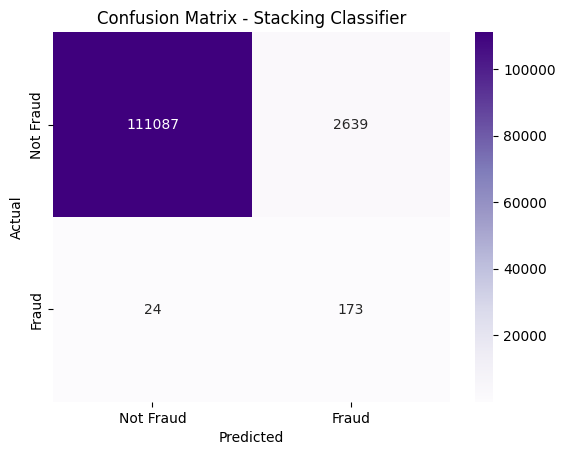

In [100]:

# --- Define base models ---
base_estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=1000, class_weight="balanced"))
]

# --- Meta-model (final classifier) ---
meta_model = LogisticRegression(max_iter=1000, class_weight="balanced")

# --- Train Stacking Classifier ---
stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    passthrough=True,       # pass original features to meta-model
    n_jobs=-1
)
stack_model.fit(X_train, y_train)

# --- Predict ---
y_pred_stack = stack_model.predict(X_test)

# --- Evaluate ---
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1-score:", f1_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

# --- Step 6: Confusion Matrix ---
cm_stack = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Not Fraud","Fraud"],
            yticklabels=["Not Fraud","Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Classifier")
plt.show()


# Model Evaluation and Comparison

<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr style="background-color:#f2f2f2;">
      <th>Model</th>
      <th>Accuracy</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Decision Tree</td>
      <td>0.9994031056064183</td>
      <td>0.8603351955307262</td>
      <td>0.7817258883248731</td>
      <td>0.8191489361702128</td>
    </tr>
    <tr>
      <td>Random Forest</td>
      <td>0.9994645506175224</td>
      <td>0.9594594594594594</td>
      <td>0.7208121827411168</td>
      <td>0.8231884057971014</td>
    </tr>
    <tr>
      <td>AdaBoost</td>
      <td>0.9990519912572527</td>
      <td>0.7730061349693251</td>
      <td>0.6395939086294417</td>
      <td>0.7000000000000000</td>
    </tr>
    <tr>
      <td>Stacking</td>
      <td>0.9766245622042958</td>
      <td>0.06152204836415363</td>
      <td>0.8781725888324873</td>
      <td>0.11498836822864739</td>
    </tr>
  </tbody>
</table>


# Analysis of Findings

Across all four models, the evaluation highlights the classic trade‑offs in fraud detection. The **Decision Tree** provided a solid baseline, with balanced precision and recall and an F1‑score just above 0.81. It is easy to interpret and quick to train, but as a single learner it risks overfitting and lacks the robustness of ensemble methods.  

The **Random Forest** stood out as the most reliable performer. By averaging many trees, it achieved the highest precision (around 0.96) and a strong F1‑score, though its recall was slightly lower than the Decision Tree. This makes it particularly effective when minimizing false alarms is important, and its stability across different splits is a clear advantage.  

The **AdaBoost Classifier** showed weaker recall compared to the other ensembles, catching fewer fraud cases. While boosting is designed to reduce bias by focusing on misclassified examples, in this dataset it struggled to balance precision and recall, resulting in a lower F1‑score. Its sensitivity to noise and outliers is a disadvantage in highly imbalanced data.  

The **Stacking Classifier** produced the most extreme results: recall was very high (close to 0.88), meaning it detected nearly all fraud cases, but precision collapsed to just over 0.06. This indicates that while stacking caught almost every fraud, it also flagged a huge number of legitimate transactions incorrectly. In practice, such a model would overwhelm a fraud detection system with false positives unless carefully tuned.  

**Random Forest emerged as the best model** in this comparison. It balanced precision and recall effectively, maintained excellent accuracy, and delivered the strongest F1‑score. Its ensemble nature makes it robust against overfitting and well‑suited to imbalanced datasets. Decision Trees remain useful for interpretability, AdaBoost requires careful tuning to shine, and Stacking demonstrates the potential for very high recall but needs refinement to be practical.  

Random Forest offers the most dependable balance for fraud detection, while Stacking shows promise if precision can be improved.